Epoch 1/300


C:\Users\salon\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 3165.0564 - val_loss: 3003.7402
Epoch 2/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2993.9185 - val_loss: 2941.4683
Epoch 3/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2862.6582 - val_loss: 2893.5083
Epoch 4/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2726.1851 - val_loss: 2852.8484
Epoch 5/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2584.8228 - val_loss: 2835.6458
Epoch 6/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2450.6453 - val_loss: 2764.5955
Epoch 7/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2307.4250 - val_loss: 2680.3987
Epoch 8/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2163.1025 - val_loss: 2426.6973
Epoch 9/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2011.9188 - val_loss: 2209.8425
Epoch 10/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1867.4705 - val_loss: 1921.0363
Epoch 11/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1738.9480 - val_loss: 1709.6556
Epoch 12

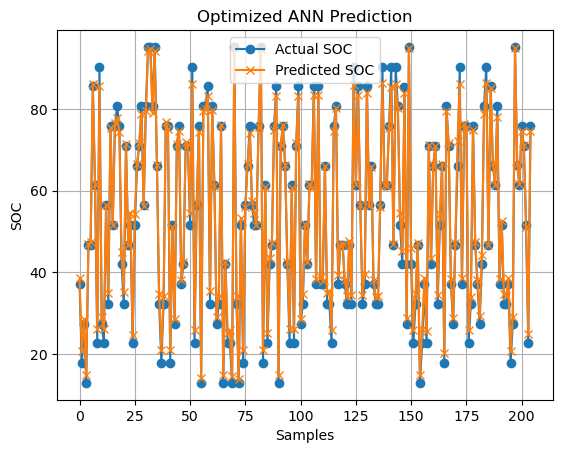

In [3]:
# ==========================================================
# OPTIMIZED ANN (MLP) REGRESSION - FINAL VERSION
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================================
# LOAD DATASET
# ==========================================================


data = pd.read_csv("final_dataset.csv")
# ==========================================================
# DATA CLEANING
# ==========================================================

data = data.drop_duplicates()
data = data.fillna(data.median(numeric_only=True))

# ==========================================================
# REMOVE OUTLIERS (IQR METHOD)
# ==========================================================

cols = ['battery_current', 'battery_voltage', 'soc']

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower) & (data[col] <= upper)]

# ==========================================================
# FEATURES & TARGET
# ==========================================================

if 'soc_coulomb' in data.columns:
    X = data[['battery_current', 'battery_voltage', 'soc_coulomb']]
else:
    X = data[['battery_current', 'battery_voltage']]

y = data['soc']

# ==========================================================
# TRAIN-TEST SPLIT (BEFORE SCALING ✅)
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================================
# NORMALIZATION (NO DATA LEAKAGE ✅)
# ==========================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# BUILD OPTIMIZED MLP MODEL
# ==========================================================

model = Sequential([

    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# ==========================================================
# CALLBACKS (VERY IMPORTANT)
# ==========================================================



# ==========================================================
# TRAIN MODEL
# ==========================================================

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    verbose=1
)

# ==========================================================
# PREDICTION
# ==========================================================

pred = model.predict(X_test).flatten()

# ==========================================================
# METRICS
# ==========================================================

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("\n===== OPTIMIZED ANN RESULTS =====")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

# ==========================================================
# PLOT 1: ACTUAL vs PREDICTED
# ==========================================================

plt.figure()
plt.plot(y_test.values, 'o-', label='Actual SOC')
plt.plot(pred, 'x-', label='Predicted SOC')
plt.legend()
plt.title('Optimized ANN Prediction')
plt.xlabel('Samples')
plt.ylabel('SOC')
plt.grid()
plt.show()
#==========================================================


In [4]:
# ===============================
# TRAINING PERFORMANCE
# ===============================
train_pred = model.predict(X_train).flatten()

train_r2 = r2_score(y_train, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

# ===============================
# TESTING PERFORMANCE
# ===============================
test_r2 = r2
test_rmse = rmse

print("\n===== PERFORMANCE =====")
print(f"Training R2  : {train_r2:.4f}")
print(f"Testing R2   : {test_r2:.4f}")

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE : {test_rmse:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

===== PERFORMANCE =====
Training R2  : 0.9930
Testing R2   : 0.9932
Training RMSE: 1.9505
Testing RMSE : 1.9383


In [5]:
from tensorflow.keras.models import save_model

# Save model
model.save("ann_model.h5")

In [6]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [3]:
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# ===============================
# LOAD MODEL & SCALER
# ===============================
model = load_model("ann_model.h5", compile=False)
scaler = joblib.load("scaler.pkl")

# ===============================
# MANUAL TEST INPUT
# ===============================
# Example values (change these)
voltage = 13.95
current = 27.00

# Create input array
input_data = np.array([[current,voltage]])

# Scale input
input_scaled = scaler.transform(input_data)

# Predict
prediction = model.predict(input_scaled)

# Convert to scalar
soc = float(prediction.flatten()[0])
soc = float(prediction.flatten()[0])
soc = max(0, min(100, soc))

# ===============================
# OUTPUT
# ===============================
print("===== TEST PREDICTION =====")
print(f"Voltage : {voltage} V")
print(f"Current : {current} A")
print(f"Predicted SOC : {soc:.2f}%")

C:\Users\salon\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
===== TEST PREDICTION =====
Voltage : 13.95 V
Current : 27.0 A
Predicted SOC : 100.00%


In [ ]:
!streamlit run app.py